In [ ]:
pip install kaggle

In [6]:
from google.colab import userdata
import os, json

kaggle_info = {
    "username": userdata.get("KAGGLE_USERNAME"),
    "key": userdata.get("KAGGLE_KEY")
}

os.makedirs("/root/.kaggle", exist_ok=True)

with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_info, f)

os.chmod("/root/.kaggle/kaggle.json", 600)

In [ ]:
!pip install kaggle
!kaggle datasets download -d yasserh/breast-cancer-dataset
!unzip breast-cancer-dataset.zip

In [ ]:
pip install pandas numpy scikit-learn torch

In [9]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [10]:
df = pd.read_csv("breast-cancer.csv")

# Drop unnecessary column if exists
if 'id' in df.columns:
    df = df.drop('id', axis=1)

# Convert diagnosis to numeric
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

X = df.drop('diagnosis', axis=1).values
y = df['diagnosis'].values

In [11]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

In [22]:
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))

In [20]:
class SVMModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x)

#**trainning of both models:-**

# logistic regression with **gardient**

In [89]:
def train_logistic_adam(X_train, y_train, X_test, y_test, epochs=100, lr=0.01):
    import torch
    import torch.nn as nn

    class LogisticRegressionModel(nn.Module):
        def __init__(self, input_dim):
            super().__init__()
            self.linear = nn.Linear(input_dim, 1)

        def forward(self, x):
            return torch.sigmoid(self.linear(x))

    model = LogisticRegressionModel(X_train.shape[1])

    # 🔥 Adam optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Loss
    criterion = nn.BCELoss()

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        optimizer.zero_grad()

        # Train step
        model.train()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        # Evaluate on test set
        model.eval() # Set model to evaluation mode
        with torch.no_grad():
            test_outputs = model(X_test)
            test_loss = criterion(test_outputs, y_test)
            test_losses.append(test_loss.item())
    model.train() # Set model back to training mode

    return model, train_losses, test_losses

In [52]:

import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    y=losses,
    mode='lines+markers',
    name='Loss'
))

fig.update_layout(
    title="Gradient Descent (Loss vs Iterations)",
    xaxis_title="Iterations",
    yaxis_title="Loss",
    template="plotly_white"
)

fig.show()


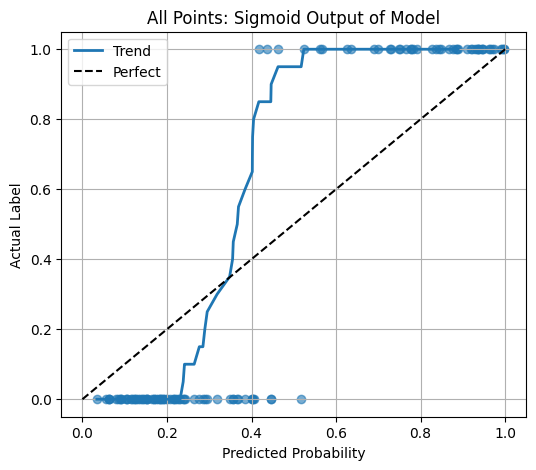

In [70]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Get predictions
model.eval()
with torch.no_grad():
    y_prob = model(X_test).numpy().flatten()
    y_true = y_test.numpy().flatten()

# Sort for better visualization
sorted_idx = np.argsort(y_prob)
y_prob_sorted = y_prob[sorted_idx]
y_true_sorted = y_true[sorted_idx]

# Plot
plt.figure(figsize=(6,5))

# All points
plt.scatter(y_prob_sorted, y_true_sorted, alpha=0.6)

# Optional: smooth sigmoid-like line (running mean)
window = 20
smooth = np.convolve(y_true_sorted, np.ones(window)/window, mode='valid')
plt.plot(y_prob_sorted[:len(smooth)], smooth, linewidth=2, label="Trend")

# Perfect line reference
plt.plot([0,1], [0,1], 'k--', label='Perfect')

plt.xlabel("Predicted Probability")
plt.ylabel("Actual Label")
plt.title("All Points: Sigmoid Output of Model")
plt.legend()
plt.grid()

plt.show()

# svm **loss**

In [53]:
def train_svm_with_loss(X_train, y_train, epochs=100, lr=0.01):
    import torch
    import torch.nn as nn

    class SVMModel(nn.Module):
        def __init__(self, input_dim):
            super().__init__()
            self.linear = nn.Linear(input_dim, 1)

        def forward(self, x):
            return self.linear(x)

    model = SVMModel(X_train.shape[1])
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    # convert labels {0,1} → {-1,1}
    y_svm = y_train.clone()
    y_svm[y_svm == 0] = -1

    losses = []

    for epoch in range(epochs):
        optimizer.zero_grad()

        outputs = model(X_train)

        # Hinge Loss
        loss = torch.mean(torch.clamp(1 - y_svm * outputs, min=0))

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return model, losses

In [54]:
import plotly.graph_objects as go
svm_model, svm_losses = train_svm_with_loss(X_train, y_train)
fig = go.Figure()

fig.add_trace(go.Scatter(
    y=svm_losses,
    mode='lines+markers',
    name='SVM Loss'
))

fig.update_layout(
    title="SVM Training (Loss vs Iterations)",
    xaxis_title="Iterations",
    yaxis_title="Hinge Loss",
    template="plotly_white"
)

fig.show()

# **svm with optimizer**

In [90]:
def train_svm_adadelta(X_train, y_train, X_test, y_test, epochs=100, rho=0.9, eps=1e-6, C=1.0):
    import torch
    import torch.nn as nn

    class SVMModel(nn.Module):
        def __init__(self, input_dim):
            super().__init__()
            self.linear = nn.Linear(input_dim, 1)

        def forward(self, x):
            return self.linear(x)

    model = SVMModel(X_train.shape[1])

    # 🔥 Adadelta optimizer
    optimizer = torch.optim.Adadelta(
        model.parameters(),
        rho=rho,
        eps=eps
    )

    # convert labels {0,1} → {-1,1}
    y_svm_train = y_train.clone()
    y_svm_train[y_svm_train == 0] = -1

    y_svm_test = y_test.clone()
    y_svm_test[y_svm_test == 0] = -1

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        optimizer.zero_grad()

        # Train step
        model.train()
        outputs = model(X_train)

        # 🔥 Hinge Loss
        hinge_loss = torch.mean(torch.clamp(1 - y_svm_train * outputs, min=0))

        # 🔥 L2 Regularization (SVM objective)
        l2_reg = torch.sum(model.linear.weight ** 2)

        # 🔥 Final Loss
        loss = 0.5 * l2_reg + C * hinge_loss

        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        # Evaluate on test set
        model.eval() # Set model to evaluation mode
        with torch.no_grad():
            test_outputs = model(X_test)
            test_hinge_loss = torch.mean(torch.clamp(1 - y_svm_test * test_outputs, min=0))
            # For consistency, also include regularization in test loss for comparison with train_loss
            test_l2_reg = torch.sum(model.linear.weight ** 2)
            test_total_loss = 0.5 * test_l2_reg + C * test_hinge_loss
            test_losses.append(test_total_loss.item())
    model.train() # Set model back to training mode

    return model, train_losses, test_losses

In [56]:
import plotly.graph_objects as go
svm_model, svm_losses = train_svm_with_optimizer(X_train, y_train)

fig = go.Figure()

fig.add_trace(go.Scatter(
    y=svm_losses,
    mode='lines+markers',
    name='SVM Loss'
))

fig.update_layout(
    title="SVM with Optimizer (Loss vs Iterations)",
    xaxis_title="Iterations",
    yaxis_title="Loss",
    template="plotly_white"
)

fig.show()

# **Results:-**

In [93]:
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
import torch
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Re-initialize X and y to ensure correct state for train_test_split
df_reinit = pd.read_csv("breast-cancer.csv")
if 'id' in df_reinit.columns:
    df_reinit = df_reinit.drop('id', axis=1)
df_reinit['diagnosis'] = df_reinit['diagnosis'].map({'M': 1, 'B': 0})
X_np_reinit = df_reinit.drop('diagnosis', axis=1).values
y_np_reinit = df_reinit['diagnosis'].values

scaler_reinit = StandardScaler()
X_scaled_reinit = scaler_reinit.fit_transform(X_np_reinit)

X_for_split = torch.tensor(X_scaled_reinit, dtype=torch.float32)
y_for_split = torch.tensor(y_np_reinit, dtype=torch.float32).view(-1, 1)


# Perform a train-test split for consistent evaluation across models and plots
# Convert torch tensors to numpy arrays and flatten y before splitting
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(X_for_split.numpy(), y_for_split.numpy().flatten(), test_size=0.2, random_state=42)

# Convert back to torch tensors with correct shapes for model training functions
X_train_plot = torch.tensor(X_train_np, dtype=torch.float32)
y_train_plot = torch.tensor(y_train_np, dtype=torch.float32).view(-1, 1)
X_test_plot = torch.tensor(X_test_np, dtype=torch.float32)
y_test_plot = torch.tensor(y_test_np, dtype=torch.float32).view(-1, 1)

# Train models and get both training and test losses
logistic_model_plot, log_train_losses, log_test_losses = train_logistic_adam(X_train_plot, y_train_plot, X_test_plot, y_test_plot)
svm_model_plot, svm_train_losses, svm_test_losses = train_svm_adadelta(X_train_plot, y_train_plot, X_test_plot, y_test_plot)

fig = go.Figure()

fig.add_trace(go.Scatter(
    y=log_train_losses,
    mode='lines',
    name='Logistic Regression (Train)',
    line=dict(color='blue')
))

fig.add_trace(go.Scatter(
    y=log_test_losses,
    mode='lines+markers',
    name='Logistic Regression (Test)',
    marker=dict(symbol='circle', size=4),
    line=dict(color='lightblue', dash='dot')
))

fig.add_trace(go.Scatter(
    y=svm_train_losses,
    mode='lines',
    name='SVM (Train)',
    line=dict(color='red')
))

fig.add_trace(go.Scatter(
    y=svm_test_losses,
    mode='lines+markers',
    name='SVM (Test)',
    marker=dict(symbol='square', size=4),
    line=dict(color='lightcoral', dash='dot')
))

fig.update_layout(
    title="Loss Comparison: Logistic vs SVM (Train & Test)",
    xaxis_title="Iterations",
    yaxis_title="Loss",
    template="plotly_white"
)

fig.show()

In [94]:
import torch
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.preprocessing import StandardScaler

def bias_variance_report(train_acc, test_acc, name="Model"):
    gap = abs(train_acc - test_acc)

    print(f"\n{name}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy : {test_acc:.4f}")
    print(f"Gap (Variance Indicator): {gap:.4f}")

    # Bias Indicator
    if train_acc > 0.95: # High training accuracy suggests low bias
        print("👉 Very Low Bias ")
    elif train_acc > 0.85:
        print("👉 Low Bias ")
    else:
        print("👉 High Bias (underfitting)")

    if gap < 0.01:
        print("👉 Very Low Variance ")
    elif gap < 0.03:
        print("👉 Low Variance ")
    else:
        print("👉 High Variance (overfitting)")

# Re-initialize X and y to ensure correct state for train_test_split
df_reinit = pd.read_csv("breast-cancer.csv")
if 'id' in df_reinit.columns:
    df_reinit = df_reinit.drop('id', axis=1)
df_reinit['diagnosis'] = df_reinit['diagnosis'].map({'M': 1, 'B': 0})
X_np_reinit = df_reinit.drop('diagnosis', axis=1).values
y_np_reinit = df_reinit['diagnosis'].values

scaler_reinit = StandardScaler()
X_scaled_reinit = scaler_reinit.fit_transform(X_np_reinit)

X_for_split = torch.tensor(X_scaled_reinit, dtype=torch.float32)
y_for_split = torch.tensor(y_np_reinit, dtype=torch.float32).view(-1, 1)


# Perform train-test split for evaluation
# Convert torch tensors to numpy arrays and flatten y before splitting
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(X_for_split.numpy(), y_for_split.numpy().flatten(), test_size=0.2, random_state=42)

# Convert back to torch tensors with correct shapes for model training and evaluation
X_train = torch.tensor(X_train_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32).view(-1, 1) # y_train needs to be (N,1) for BCELoss
X_test = torch.tensor(X_test_np, dtype=torch.float32)
y_test = torch.tensor(y_test_np, dtype=torch.float32).view(-1, 1) # y_test also needs to be (N,1) for criterion in train_logistic_adam

# Train models using previously defined functions (passing test data for signature consistency)
logistic_model, _, _ = train_logistic_adam(X_train, y_train, X_test, y_test)
svm_model, _, _ = train_svm_adadelta(X_train, y_train, X_test, y_test)

# ===== Logistic Regression Evaluation =====
logistic_model.eval()
with torch.no_grad():
    log_train_pred = (logistic_model(X_train) >= 0.5).numpy()
    log_test_pred = (logistic_model(X_test) >= 0.5).numpy()

log_train_acc = accuracy_score(y_train_np, log_train_pred) # Use 1D numpy y for accuracy_score
log_test_acc = accuracy_score(y_test_np, log_test_pred) # Use 1D numpy y for accuracy_score

bias_variance_report(log_train_acc, log_test_acc, name="Logistic Regression")

# ===== SVM Evaluation =====
svm_model.eval()
with torch.no_grad():
    # For SVM, a positive output generally means class 1, negative means class 0 (or -1 in SVM context)
    svm_train_pred = (svm_model(X_train) >= 0).numpy()
    svm_test_pred = (svm_model(X_test) >= 0).numpy()

svm_train_acc = accuracy_score(y_train_np, svm_train_pred) # Use 1D numpy y for accuracy_score
svm_test_acc = accuracy_score(y_test_np, svm_test_pred) # Use 1D numpy y for accuracy_score

bias_variance_report(svm_train_acc, svm_test_acc, name="SVM")


Logistic Regression
Train Accuracy: 0.9802
Test Accuracy : 0.9912
Gap (Variance Indicator): 0.0110
👉 Very Low Bias 
👉 Low Variance 

SVM
Train Accuracy: 0.9516
Test Accuracy : 0.9649
Gap (Variance Indicator): 0.0133
👉 Very Low Bias 
👉 Low Variance 
